In [1]:
#
# ⚡ UNIVERSAL FIRST CELL - Run this FIRST in every notebook!
# Compatible with: Google Colab, GitHub Codespaces, Local
#

import os
import subprocess
import sys

# Detect environment
IS_COLAB = "google.colab" in sys.modules
IS_CODESPACES = os.path.exists("/.devcontainer") or os.path.exists("/workspaces")
IS_LOCAL = not (IS_COLAB or IS_CODESPACES)

print(f"🚀 Environment: {'Colab' if IS_COLAB else 'Codespaces' if IS_CODESPACES else 'Local'}")

# Ensure we are in the root directory for relative paths
while not os.path.exists('data') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
print(f"📁 Working directory set to: {os.getcwd()}")

print("✅ Environment ready!")


🚀 Environment: Local
📁 Working directory set to: /home/aidmantas/repos/computer-data-analysis-report
✅ Environment ready!


# ML Training: AI Data Center Promise Feasibility

This notebook trains a predictive model to determine if a data center buildout promise will be kept based on:
1. **Company Tier** (Hyperscaler vs. REIT)
2. **Regional Grid Pressure** (ISO queue depth)
3. **Macroeconomics** (GDP, CPI, Interest Rates)
4. **Timeline Constraints** (Days to target)

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the merged dataset
df = pd.read_csv("data/processed/dataset_for_ml.csv")
print(f"📊 Dataset Loaded: {df.shape}")
df.head()

📊 Dataset Loaded: (34, 23)


,company,announcement_date,promised_mw,location,iso,company_ticker,company_tier,target_date,actual_date,promise_kept,...,tier_TIER_4,days_to_target,announcement_quarter,Real GDP,Core CPI,Fed Funds Rate,Unemployment Rate,30Y Mortgage Rate,10Y Treasury,iso_queue_depth
0,Microsoft,2021-03-01,100,"Phoenix, AZ",CAISO,TICKER_MSFT,TIER_1,2023-12-01,2024-01-15,1,...,False,1005,2021Q1,21082.134,271.459,0.07,6.1,3.17,1.74,3.0
1,Microsoft,2022-06-15,150,"San Antonio, TX",ERCOT,TICKER_MSFT,TIER_1,2024-06-15,2024-05-01,1,...,False,731,2022Q2,21967.045,294.050,1.21,3.6,5.70,2.98,0.0
2,Microsoft,2022-11-01,200,"West Des Moines, IA",MISO,TICKER_MSFT,TIER_1,2024-11-01,2024-10-15,1,...,False,731,2022Q4,22278.345,301.394,4.10,3.5,6.42,3.88,0.0
3,Microsoft,2024-01-15,250,"Mount Pleasant, WI",MISO,TICKER_MSFT,TIER_1,2026-01-15,NaN,0,...,False,731,2024Q1,23082.119,316.792,5.33,3.9,6.79,4.20,0.0
4,Google,2021-09-01,120,"Dallas, TX",ERCOT,TICKER_GOOGL,TIER_1,2023-09-01,2023-08-15,1,...,False,730,2021Q3,21617.828,279.698,0.08,4.7,3.01,1.52,0.0


## 1. Preprocessing

In [3]:
# Handle categorical variables
le_iso = LabelEncoder()
df['iso_encoded'] = le_iso.fit_transform(df['iso'])

le_tier = LabelEncoder()
df['tier_encoded'] = le_tier.fit_transform(df['company_tier'])

# Define Features (Numerical + Encoded)
features = [
    'promised_mw', 
    'days_to_target', 
    'iso_encoded', 
    'tier_encoded',
    'Real GDP', 
    'Core CPI', 
    'Fed Funds Rate', 
    'Unemployment Rate', 
    '30Y Mortgage Rate', 
    '10Y Treasury',
    'iso_queue_depth'
]

X = df[features].copy()
y = df['promise_kept'].copy()

# Fill any missing values with median
X = X.fillna(X.median())

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (27, 11), Test set: (7, 11)


## 2. Model Training: XGBoost

In [4]:
# Detect GPU
try:
    subprocess.check_output('nvidia-smi')
    device = "cuda"
    print("✅ GPU detected! Training on CUDA.")
except:
    device = "cpu"
    print("⚠️ No GPU detected. Using CPU.")

# Initialize and train
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    device=device,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
if len(np.unique(y_test)) > 1:
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

⚠️ No GPU detected. Using CPU.



=== XGBoost Evaluation ===
Accuracy: 0.8571
ROC-AUC: 0.9500
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.83      1.00      0.91         5

    accuracy                           0.86         7
   macro avg       0.92      0.75      0.79         7
weighted avg       0.88      0.86      0.84         7



## 3. Feature Importance

/tmp/ipykernel_40730/1570759327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


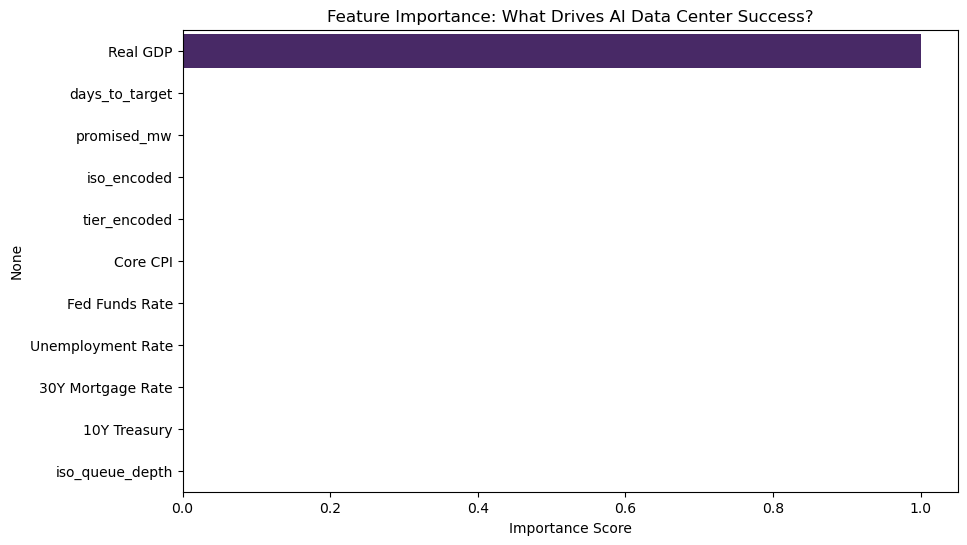

Top Drivers:
Real GDP          1.0
days_to_target    0.0
promised_mw       0.0
iso_encoded       0.0
tier_encoded      0.0
dtype: float32


In [5]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance: What Drives AI Data Center Success?")
plt.xlabel("Importance Score")
plt.show()

print("Top Drivers:")
print(importances.head())